# Intelligent Tire — Circumferential Inner-Liner Strain & Piezoelectric Response

**10.00R20 medium-duty truck tire, free rolling on asphalt.**

First-order analytical model of the circumferential (rolling-direction) strain on the
tire inner liner as it passes through a flat-road contact patch, and the piezoelectric
charge waveform that strain induces in a surface-bonded patch.

The objective is a physically *consistent* signal generator for sensing and
energy-harvesting studies — not finite-element accuracy.

| Quantity | Value |
|---|---|
| Tire size | 10.00R20 |
| Inflated radius $R$ | 0.53 m |
| Section width | 0.27 m |
| Static vertical load | 40 kN |
| Inflation pressure | 827 kPa |
| Speed | 40 km/h (11.11 m/s) |
| Slip | 0 (free rolling) |
| Surface | asphalt |

### Sign convention

Strain is referenced to the **free-rolling inflated state**: the static inflation hoop
strain is the zero. Positive = circumferential tension. Only this AC component drives a
piezoelectric harvester, so this is the useful reference.

### What the model guarantees

Rather than tuning a shape until it looks right, each feature is pinned to a physical
argument, and the notebook checks the result numerically at the end:

1. **Contact patch length** follows from vertical equilibrium, $A = F/(k_p\,p)$, with the
   width fixed by the tread — so load growth goes into patch *length*.
2. **Peak strain** follows from belt flattening: curvature changes from $1/R$ to $\approx 0$,
   so a fibre at offset $h$ from the neutral axis sees $\varepsilon \approx h/R$.
3. **Closed-loop kinematics**: a material point on a closed loop returns to its original
   length every revolution, so $\oint \varepsilon\,ds = 0$.
4. **Smoothness**: the field is $C^\infty$ everywhere. No clipping, no masking, no hard zeroing.
5. **Speed** enters the electrical result through $i = dQ/dt$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

from tire_strain_model import (
    TireParams, PiezoParams,
    strain_field, circumferential_profile, width_profile,
    charge_waveform, current_waveform, consistency_report,
)

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

# ---- Adjustable parameters (requirement F) -------------------------------- #
# Any of these can be changed; everything downstream re-derives itself.
tire = TireParams(
    load=40_000.0,              # N
    inflation_pressure=827e3,   # Pa
    speed=40 / 3.6,             # m/s
    # contact_patch_length=...  # m   -> optional override, else from equilibrium
    # peak_strain=...           # ue  -> optional override, else from curvature
)
piezo = PiezoParams(
    d33=550e-12,            # C/N
    youngs_modulus=24.4e9,  # Pa
    patch_length=132e-3,    # m, along the ROLLING direction
    patch_width=10e-3,      # m, across the tread
)

print(f"contact patch length   {tire.L*1e3:7.1f} mm   (derived from load/pressure)")
print(f"contact width          {tire.contact_width*1e3:7.1f} mm")
print(f"mean contact pressure  {tire.load/tire.contact_area/1e3:7.0f} kPa "
      f"({tire.load/tire.contact_area/tire.inflation_pressure:.2f}x inflation)")
print(f"peak tensile strain    {tire.eps_peak:7.0f} ue  (= h/R, h = {tire.neutral_axis_offset*1e3:.2f} mm)")
print(f"rotation frequency     {tire.rotation_frequency:7.2f} Hz  -> period {1/tire.rotation_frequency*1e3:.0f} ms")
print(f"patch residence time   {tire.patch_residence_time*1e3:7.1f} ms")

contact patch length     199.7 mm   (derived from load/pressure)
contact width            210.6 mm
mean contact pressure      951 kPa (1.15x inflation)
peak tensile strain       2511 ue  (= h/R, h = 1.38 mm)
rotation frequency        3.34 Hz  -> period 300 ms
patch residence time      18.0 ms


## The strain profile, region by region

The rolling-direction shape $f(s)$ is built from three physically distinct pieces.
Plotting them separately makes the physical reading explicit.

**1 — Tensile plateau (inside the patch).** The belt is pressed flat against the road.
Curvature drops from $1/R$ to $\approx 0$, and the inner liner, sitting *inside* the
neutral axis, is stretched. Because the patch is genuinely flat over most of its length
this is a flat-topped super-Gaussian, **not** a narrow bell — a plain Gaussian would
wrongly imply the strain peaks only at the exact patch centre.

**2 — Entry / exit compression lobes (just *outside* the patch).** Immediately before
entry and after exit the carcass bends locally into and out of the flat. Curvature there
is *higher* than $1/R$, which reverses the sign and puts the liner in compression. These
lobes are centred outside $\pm L/2$, which is where they physically occur.

**3 — Distributed offset (over the free circumference).** The tensile pulse is large but
short; it is balanced by a small compressive offset spread over the whole remaining
circumference so that $\oint \varepsilon\,ds = 0$. This offset is *computed* from the
constraint, not tuned.

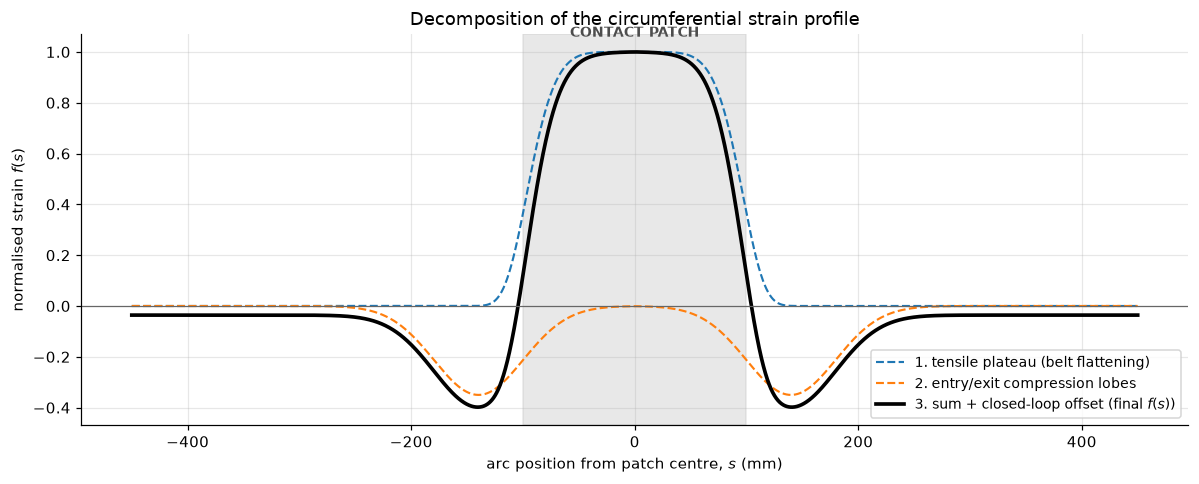

tension -> compression crossing at 104.3 mm  (patch edge is 99.9 mm -> crossing is OUTSIDE the patch, as required)


In [2]:
s = np.linspace(-0.45, 0.45, 4000)
L = tire.L
a, m = L / 2, tire.tension_flatness
sig = tire.compression_spread * L
s0 = a + sig

tension = np.exp(-((np.abs(s) / a) ** (2 * m)))
compression = -tire.compression_ratio * np.exp(-((np.abs(s) - s0) ** 2) / (2 * sig ** 2))
total = circumferential_profile(s, tire)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(s * 1e3, tension, "--", lw=1.4, label="1. tensile plateau (belt flattening)")
ax.plot(s * 1e3, compression, "--", lw=1.4, label="2. entry/exit compression lobes")
ax.plot(s * 1e3, total, "k", lw=2.4, label="3. sum + closed-loop offset (final $f(s)$)")
ax.axvspan(-L/2*1e3, L/2*1e3, color="0.75", alpha=0.35, zorder=0)
ax.text(0, 1.06, "CONTACT PATCH", ha="center", fontsize=9, weight="bold", color="0.3")
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xlabel("arc position from patch centre, $s$ (mm)")
ax.set_ylabel("normalised strain $f(s)$")
ax.set_title("Decomposition of the circumferential strain profile")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

zero = s[(s > 0) & (np.diff(np.sign(total), append=0) != 0)]
print(f"tension -> compression crossing at {zero[0]*1e3:.1f} mm  "
      f"(patch edge is {L/2*1e3:.1f} mm -> crossing is OUTSIDE the patch, as required)")

## A. 2D strain map

The domain deliberately extends **beyond** the contact patch in the rolling direction, so
that the pre-entry and post-exit compression zones (requirements 1 and 3) are actually
visible rather than off-canvas. Axes are drawn to true physical scale — the patch is
about twice as wide as it is long, and the plot shows that honestly.

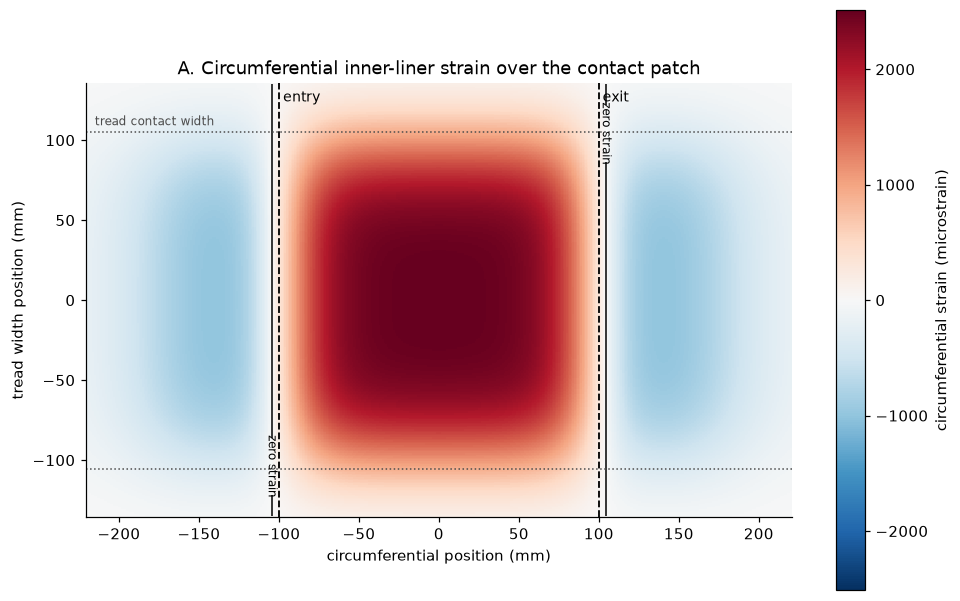

field shape (441, 271)   max 2511 ue   min -1000 ue
strain at shoulder (y = +-135 mm), patch centre: 168 ue (6.7% of peak)


In [3]:
s_ax = np.linspace(-0.22, 0.22, 441)      # rolling direction, beyond the patch
y_ax = np.linspace(-tire.section_width/2, tire.section_width/2, 271)
S, Y = np.meshgrid(s_ax, y_ax, indexing="ij")
field = strain_field(S, Y, tire)          # (n_s, n_y), microstrain

vmax = np.abs(field).max()
norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(9, 6.5))
pc = ax.pcolormesh(S*1e3, Y*1e3, field, cmap="RdBu_r", norm=norm, shading="auto")
cs = ax.contour(S*1e3, Y*1e3, field, levels=[0], colors="k", linewidths=1.0)
ax.clabel(cs, fmt={0: "zero strain"}, fontsize=8)

for xe, lab in [(-tire.L/2*1e3, "entry"), (tire.L/2*1e3, "exit")]:
    ax.axvline(xe, color="k", ls="--", lw=1.2)
    ax.text(xe, tire.section_width/2*1e3*0.92, f" {lab}", fontsize=9)
ax.axhline(tire.contact_width/2*1e3, color="0.3", ls=":", lw=1)
ax.axhline(-tire.contact_width/2*1e3, color="0.3", ls=":", lw=1)
ax.text(-215, tire.contact_width/2*1e3+4, "tread contact width", fontsize=8, color="0.3")

ax.set_aspect("equal")                     # true geometric proportions
ax.set_xlabel("circumferential position (mm)")
ax.set_ylabel("tread width position (mm)")
ax.set_title("A. Circumferential inner-liner strain over the contact patch")
fig.colorbar(pc, ax=ax, label="circumferential strain (microstrain)", shrink=0.85)
ax.grid(False)
plt.tight_layout(); plt.show()

print(f"field shape {field.shape}   max {field.max():.0f} ue   min {field.min():.0f} ue")
print(f"strain at shoulder (y = +-135 mm), patch centre: {strain_field(0.0, tire.section_width/2, tire):.0f} ue "
      f"({width_profile(np.array(tire.section_width/2), tire)*100:.1f}% of peak)")

## B. 3D surface

Same field, viewed as a surface. The plateau across the patch, the two compression
troughs flanking it, and the roll-off toward both shoulders are all visible as one
continuous, differentiable sheet.

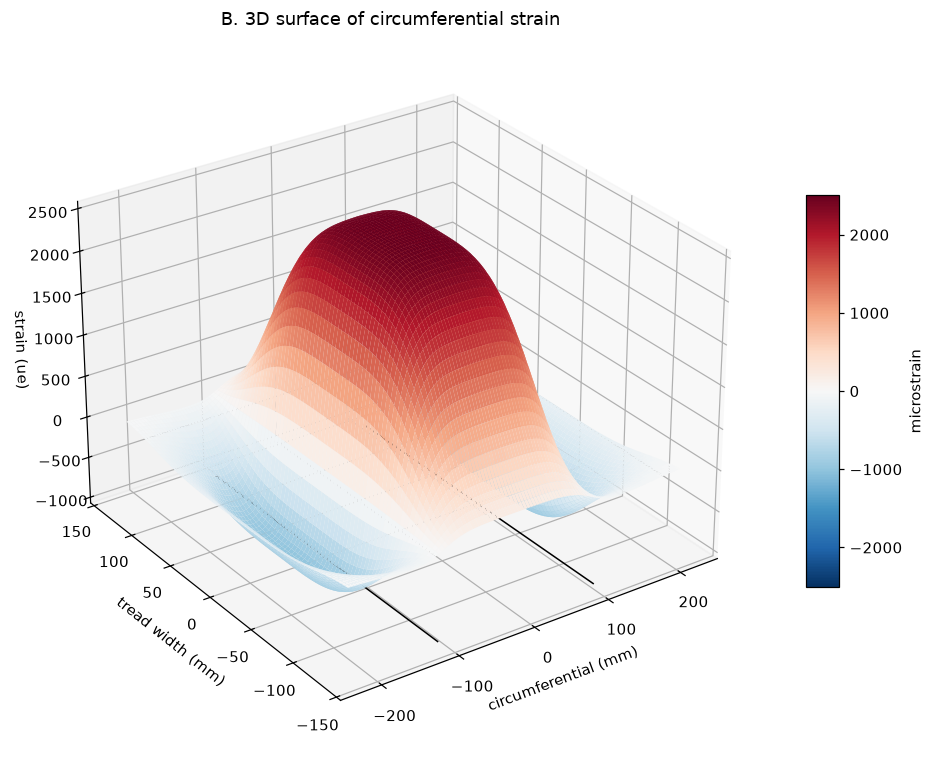

In [4]:
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S*1e3, Y*1e3, field, cmap="RdBu_r", norm=norm,
                       rstride=4, cstride=4, linewidth=0, antialiased=True)
ax.contour(S*1e3, Y*1e3, field, levels=[0], colors="k", linewidths=1,
           offset=field.min()*1.05, zdir="z")
ax.set_xlabel("circumferential (mm)"); ax.set_ylabel("tread width (mm)")
ax.set_zlabel("strain (ue)")
ax.set_title("B. 3D surface of circumferential strain")
ax.view_init(elev=28, azim=-125)
fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, label="microstrain")
plt.tight_layout(); plt.show()

## C. Strain history over one full revolution

A single material point on the centreline, tracked through one complete rotation. Both a
distance axis and a **time** axis are shown — the time axis is where `speed` first enters,
via $t = s/v$.

Note the small negative offset away from the patch: that is the distributed compression
enforcing $\oint \varepsilon\,ds = 0$, not a numerical artefact. The signal is continuous
and differentiable everywhere, including at the ends of the revolution, so no masking or
clipping is applied anywhere.

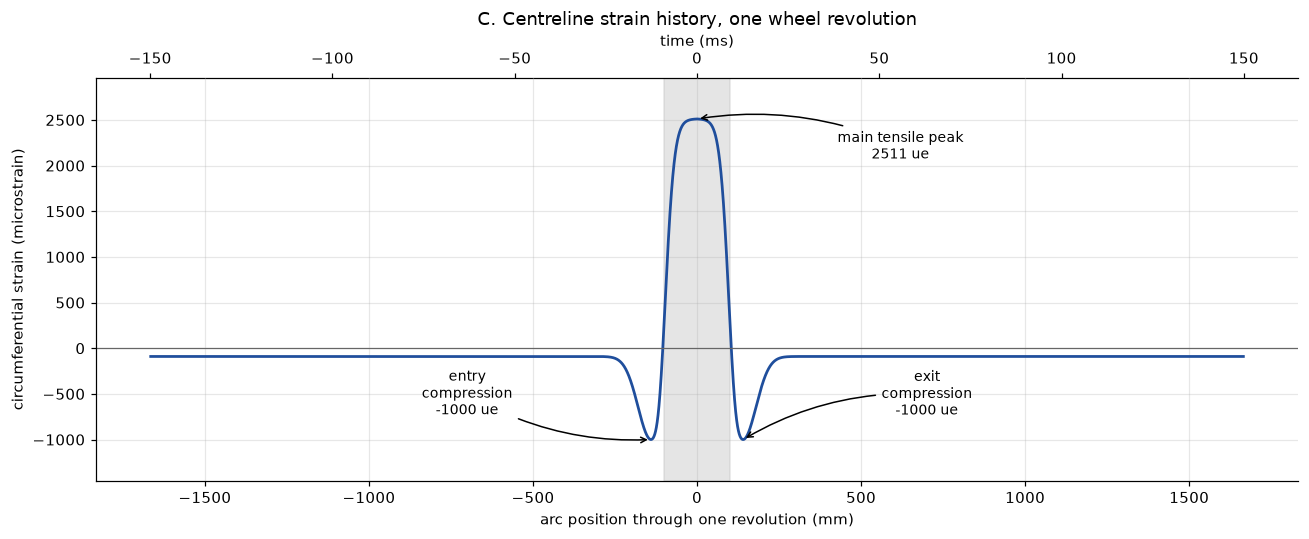

revolution period      300 ms
samples inside patch   1199  (the event is well resolved)
peak / entry / exit    2511 / -1000 / -1000 ue
off-patch offset       -90.0 ue  (closed-loop balance)


In [5]:
n_rev = 20001                                     # >=100 samples across the patch
s_rev = np.linspace(-tire.circumference/2, tire.circumference/2, n_rev)
eps_rev = strain_field(s_rev, 0.0, tire)
t_rev = s_rev / tire.speed

samples_in_patch = int((np.abs(s_rev) <= tire.L/2).sum())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_rev*1e3, eps_rev, lw=1.8, color="#1f4e9c")
ax.axvspan(-tire.L/2*1e3, tire.L/2*1e3, color="0.75", alpha=0.4, zorder=0)
ax.axhline(0, color="0.4", lw=0.8)

i_pk = np.argmax(eps_rev)
i_en = np.argmin(np.where(s_rev < 0, eps_rev, np.inf))
i_ex = np.argmin(np.where(s_rev > 0, eps_rev, np.inf))
# annotate well clear of the pulse: the x axis spans 3330 mm but the whole event
# occupies ~300 mm of it, so label offsets have to be large in data units
for i, lab, dx, dy in [(i_en, "entry\ncompression", -560, 500),
                       (i_pk, "main tensile peak", 620, -300),
                       (i_ex, "exit\ncompression", 560, 500)]:
    ax.annotate(f"{lab}\n{eps_rev[i]:.0f} ue",
                xy=(s_rev[i]*1e3, eps_rev[i]),
                xytext=(s_rev[i]*1e3 + dx, eps_rev[i] + dy),
                fontsize=9, ha="center", va="center",
                arrowprops=dict(arrowstyle="->", lw=1, connectionstyle="arc3,rad=0.15"))
ax.set_ylim(eps_rev.min() - 450, eps_rev.max() + 450)

ax.set_xlabel("arc position through one revolution (mm)")
ax.set_ylabel("circumferential strain (microstrain)")
ax.set_title("C. Centreline strain history, one wheel revolution")

sec = ax.secondary_xaxis("top", functions=(lambda x: x/1e3/tire.speed*1e3,
                                           lambda t: t/1e3*tire.speed*1e3))
sec.set_xlabel("time (ms)")
plt.tight_layout(); plt.show()

print(f"revolution period      {1/tire.rotation_frequency*1e3:.0f} ms")
print(f"samples inside patch   {samples_in_patch}  (the event is well resolved)")
print(f"peak / entry / exit    {eps_rev.max():.0f} / {eps_rev[i_en]:.0f} / {eps_rev[i_ex]:.0f} ue")
print(f"off-patch offset       {eps_rev[0]:.1f} ue  (closed-loop balance)")

### Zoom on the contact event

The whole electrically useful signal happens in about 18 ms out of a 300 ms revolution —
a ~6% duty cycle. That is the key constraint on harvester circuit design.

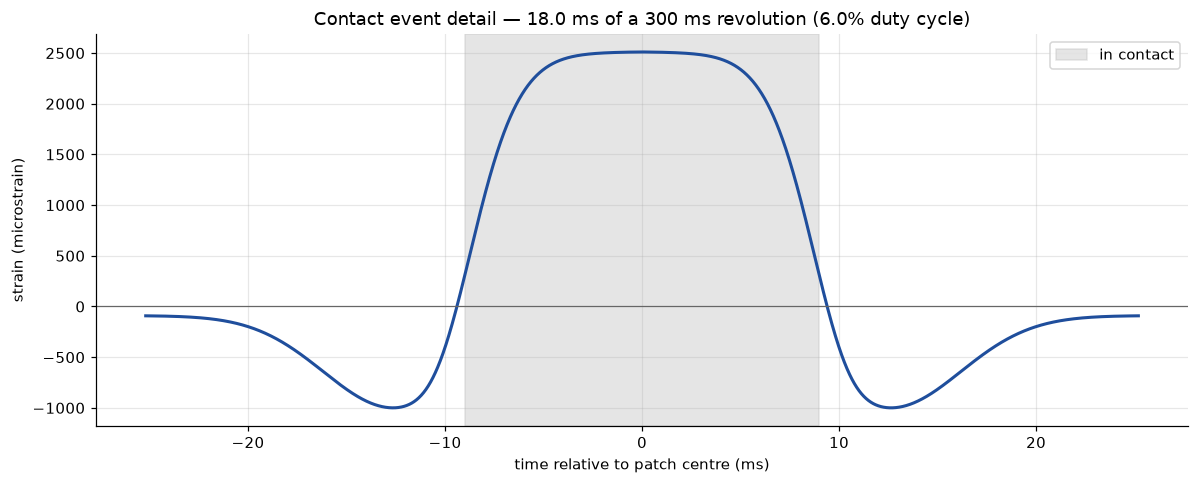

In [6]:
win = np.abs(s_rev) <= 0.28
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_rev[win]*1e3, eps_rev[win], lw=2, color="#1f4e9c")
ax.axvspan(-tire.patch_residence_time/2*1e3, tire.patch_residence_time/2*1e3,
           color="0.75", alpha=0.4, zorder=0, label="in contact")
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xlabel("time relative to patch centre (ms)")
ax.set_ylabel("strain (microstrain)")
ax.set_title(f"Contact event detail — {tire.patch_residence_time*1e3:.1f} ms of a "
             f"{1/tire.rotation_frequency*1e3:.0f} ms revolution "
             f"({tire.patch_residence_time*tire.rotation_frequency*100:.1f}% duty cycle)")
ax.legend()
plt.tight_layout(); plt.show()

## D. Export

Saved as a plain `.npy` (the strain array alone, as requested) plus an `.npz` that keeps
the axes and the parameter set alongside it, so the array is still interpretable later.

In [7]:
np.save("circumferential_strain_field.npy", field)
np.savez("circumferential_strain_field.npz",
         strain_microstrain=field,
         s_axis_m=s_ax, y_axis_m=y_ax,
         load_N=tire.load, inflation_pressure_Pa=tire.inflation_pressure,
         speed_mps=tire.speed, contact_patch_length_m=tire.L,
         contact_width_m=tire.contact_width, peak_strain_ue=tire.eps_peak,
         readme="axis 0 = circumferential (s_axis_m), axis 1 = tread width (y_axis_m); "
                "values are microstrain relative to the free-rolling inflated state")

chk = np.load("circumferential_strain_field.npy")
print(f"saved circumferential_strain_field.npy  shape {chk.shape}  dtype {chk.dtype}")
print(f"round-trip identical: {np.array_equal(chk, field)}")
print(f"range: {chk.min():.0f} to {chk.max():.0f} microstrain")

saved circumferential_strain_field.npy  shape (441, 271)  dtype float64
round-trip identical: True
range: -1000 to 2511 microstrain


## Piezoelectric charge waveform

Using the prescribed constitutive relation

$$Q = d_{33}\, E\, A\, \varepsilon$$

with $d_{33} = 550\;\mathrm{pC/N}$, $E = 24.4\;\mathrm{GPa}$, $A = 132\,\mathrm{mm} \times 10\,\mathrm{mm}$.

One change from a naive evaluation: $\varepsilon$ is the strain **averaged over the patch
footprint**, not sampled at a single point. The patch is 132 mm long and the contact patch
is 200 mm long, so the patch is never uniformly strained; a point sample misstates the
charge. (With the flat-topped profile the averaging penalty turns out to be mild — about
3% — but with a narrow-Gaussian profile it would have been a factor of ~2.6, so the
distinction is worth keeping.)

> **Caveats on absolute magnitude.** Two independent issues make the numbers below an
> optimistic *upper bound* rather than a prediction:
> 1. $d_{33}$ paired with an in-plane strain implies in-plane poling (interdigitated
>    electrodes), but $A$ is the full planar face area — the area that carries the force
>    in an IDE device is the much smaller cross-section normal to the fibre direction.
> 2. The capacitance below uses a parallel-plate expression, which describes a
>    through-thickness-electroded ($d_{31}$) device — a different electrode topology from
>    the one $d_{33}$ implies. The two assumptions are mutually inconsistent.
>
> The *shape* and *timing* of the waveform are unaffected by either issue; only the scale is.

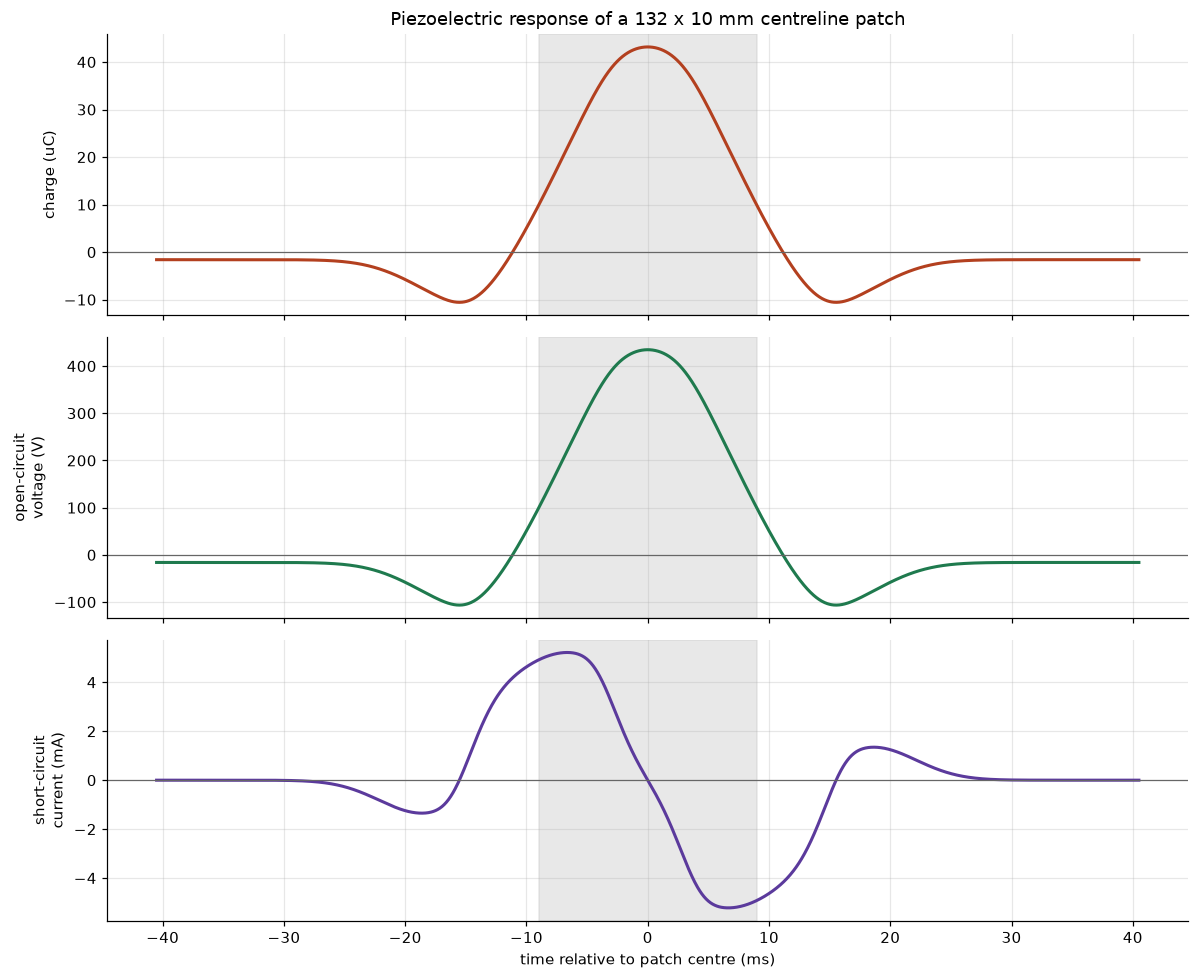

peak charge               43.17 uC
peak-to-peak charge       53.74 uC
peak open-circuit V       434.6 V   (C = 99.3 nF)
peak current               5.22 mA   <- scales linearly with speed
energy per revolution     14.54 mJ  (upper bound, see caveats)
average power             48.50 mW  (upper bound)


In [8]:
s_q = np.linspace(-0.45, 0.45, 1801)
Q = charge_waveform(s_q, tire, piezo)
I = current_waveform(Q, s_q, tire)
t_q = s_q / tire.speed
V = Q / piezo.capacitance

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(t_q*1e3, Q*1e6, lw=2, color="#b3401f")
axes[0].set_ylabel("charge (uC)")
axes[0].set_title("Piezoelectric response of a 132 x 10 mm centreline patch")

axes[1].plot(t_q*1e3, V, lw=2, color="#1f7a4e")
axes[1].set_ylabel("open-circuit\nvoltage (V)")

axes[2].plot(t_q*1e3, I*1e3, lw=2, color="#5b3a9c")
axes[2].set_ylabel("short-circuit\ncurrent (mA)")
axes[2].set_xlabel("time relative to patch centre (ms)")

for ax in axes:
    ax.axhline(0, color="0.4", lw=0.8)
    ax.axvspan(-tire.patch_residence_time/2*1e3, tire.patch_residence_time/2*1e3,
               color="0.75", alpha=0.35, zorder=0)
plt.tight_layout(); plt.show()

print(f"peak charge            {Q.max()*1e6:8.2f} uC")
print(f"peak-to-peak charge    {(Q.max()-Q.min())*1e6:8.2f} uC")
print(f"peak open-circuit V    {V.max():8.1f} V   (C = {piezo.capacitance*1e9:.1f} nF)")
print(f"peak current           {np.abs(I).max()*1e3:8.2f} mA   <- scales linearly with speed")

E_rev = (Q.max()-Q.min())**2 / (2*piezo.capacitance)
print(f"energy per revolution  {E_rev*1e3:8.2f} mJ  (upper bound, see caveats)")
print(f"average power          {E_rev*tire.rotation_frequency*1e3:8.2f} mW  (upper bound)")

### Speed genuinely matters now

Charge is set by strain and is therefore speed-independent, but current is $dQ/dt$ and
scales linearly with speed, while available power scales linearly with rotation frequency.
This is the behaviour the `speed` parameter should produce, and it is verified below.

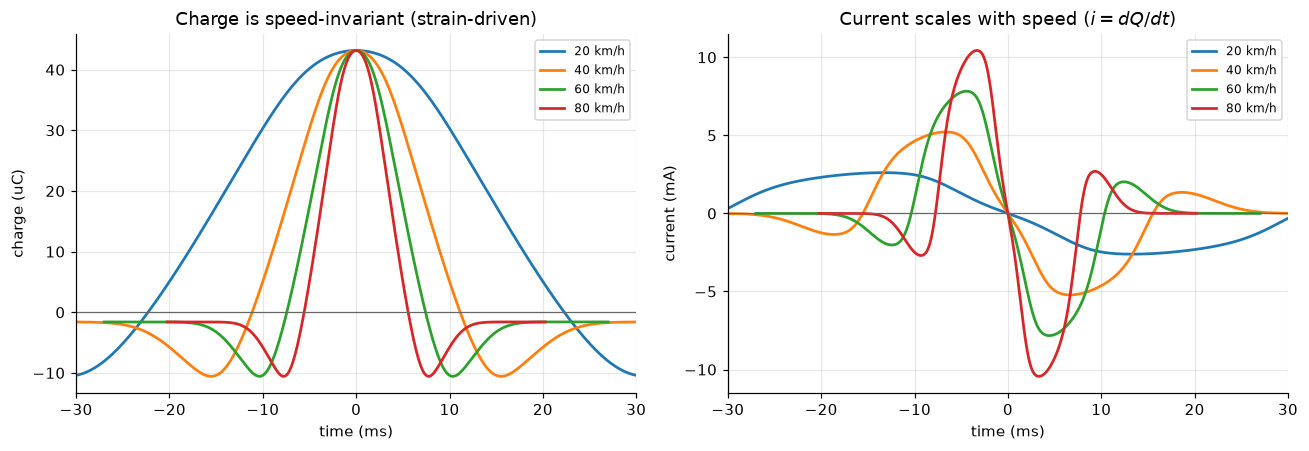

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
speeds_kmh = [20, 40, 60, 80]
for v in speeds_kmh:
    tv = TireParams(load=tire.load, inflation_pressure=tire.inflation_pressure, speed=v/3.6)
    Qv = charge_waveform(s_q, tv, piezo)
    Iv = current_waveform(Qv, s_q, tv)
    ax[0].plot(s_q/tv.speed*1e3, Qv*1e6, lw=1.8, label=f"{v} km/h")
    ax[1].plot(s_q/tv.speed*1e3, Iv*1e3, lw=1.8, label=f"{v} km/h")
ax[0].set_ylabel("charge (uC)"); ax[1].set_ylabel("current (mA)")
for a in ax:
    a.set_xlabel("time (ms)"); a.set_xlim(-30, 30); a.axhline(0, color="0.4", lw=0.8); a.legend(fontsize=8)
ax[0].set_title("Charge is speed-invariant (strain-driven)")
ax[1].set_title("Current scales with speed ($i = dQ/dt$)")
plt.tight_layout(); plt.show()

## Parameter sensitivity

Load and pressure act on the strain field through **two different channels, with very
different strengths.**

**Patch length — strong, roughly proportional.** Contact area is set by vertical
equilibrium, $A = F/(k_p p)$, and the tread width is fixed by construction, so essentially
all of it goes into length: $L \propto F/p$. Load more than doubles $L$ over 25–55 kN.

**Peak strain — weak and saturating.** The ceiling is geometric: flattening the belt
changes curvature from $1/R$ to $\approx 0$, so a fibre at offset $h$ from the neutral axis
sees at most $\varepsilon = h/R$. The road is flat no matter how hard you press on it, so
this ceiling does *not* scale with load.

But it is only *reached* insofar as the belt actually conforms. The belt is a beam under
tension $N = pR$ with bending stiffness $D$, so it relaxes into and out of the flat over a
characteristic length $\lambda = \sqrt{D/N} \approx 30$ mm. If the patch is long compared
with $\lambda$ the centre is fully flat; if it is short — a lightly loaded or heavily
inflated tire — the belt never fully flattens:

$$\varepsilon_\text{peak} = \frac{h}{R}\,\eta, \qquad \eta = 1 - e^{-L/2\lambda}$$

So peak strain *does* rise with load, just weakly and with saturation — about 13% over
25–55 kN against a 120% change in patch length. Pressure enters twice and the two effects
partly cancel: higher pressure shortens the patch (less conformity) but also tightens the
belt (shorter $\lambda$, more conformity), leaving only a ~1% net swing over 650–1000 kPa,
toward lower strain at higher pressure.

The practical consequence for harvesting: **extra load buys a longer pulse far more than a
taller one.** Energy per revolution grows mostly through duration.

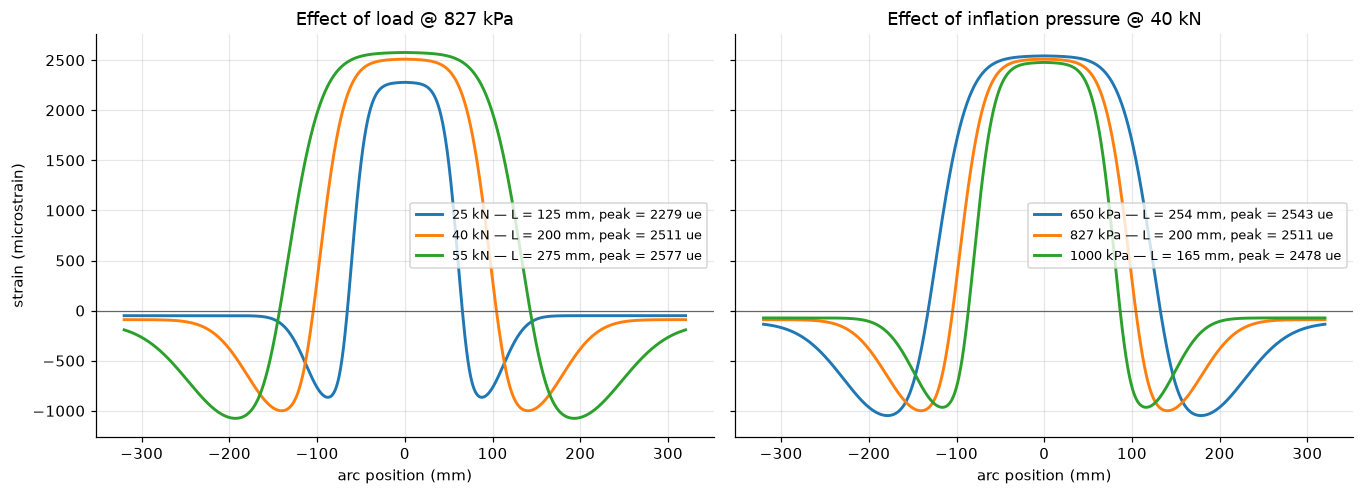

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
sv = np.linspace(-0.32, 0.32, 3000)

for F in [25e3, 40e3, 55e3]:
    tp = TireParams(load=F, inflation_pressure=tire.inflation_pressure, speed=tire.speed)
    ax[0].plot(sv*1e3, strain_field(sv, 0.0, tp), lw=1.9,
               label=f"{F/1e3:.0f} kN — L = {tp.L*1e3:.0f} mm, peak = {tp.eps_peak:.0f} ue")
ax[0].set_title("Effect of load @ 827 kPa")
ax[0].set_xlabel("arc position (mm)"); ax[0].set_ylabel("strain (microstrain)")

for P in [650e3, 827e3, 1000e3]:
    tp = TireParams(load=tire.load, inflation_pressure=P, speed=tire.speed)
    ax[1].plot(sv*1e3, strain_field(sv, 0.0, tp), lw=1.9,
               label=f"{P/1e3:.0f} kPa — L = {tp.L*1e3:.0f} mm, peak = {tp.eps_peak:.0f} ue")
ax[1].set_title("Effect of inflation pressure @ 40 kN")
ax[1].set_xlabel("arc position (mm)")

for a in ax:
    a.axhline(0, color="0.4", lw=0.8); a.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

### Why peak strain saturates

Plotting the two channels against each other over a wide load range makes the asymmetry
obvious: patch length climbs essentially without limit, while peak strain runs into the
geometric $h/R$ ceiling and flattens out. Below about 25 kN the belt genuinely fails to
conform and the peak drops off sharply — that is the regime where a naive "strain scales
with load" assumption is least wrong, and above rated load it is most wrong.

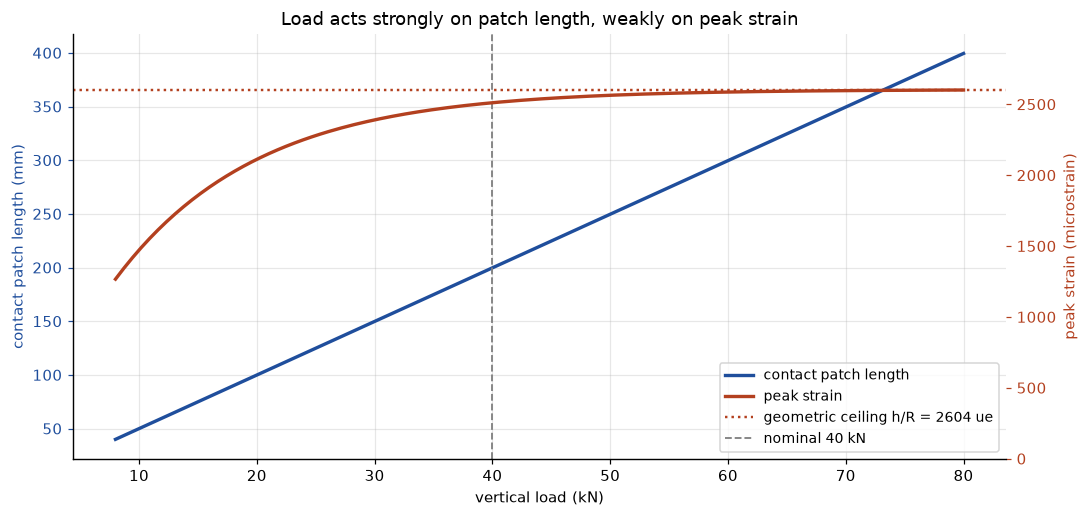

 load kN    L mm  conform  peak ue  pulse ms   E/rev uJ


      15      75    0.713     1857       6.7       1259


      25     125    0.875     2279      11.2       7146


      40     200    0.964     2511      18.0      14537


      55     275    0.990     2577      24.7      17834


      70     349    0.997     2596      31.5      19775

over 25-55 kN:  patch length x2.20,  peak strain x1.13
over 650-1000 kPa: patch length x1.54,  peak strain x1.03


In [11]:
loads = np.linspace(8e3, 80e3, 200)
Lmm = np.array([TireParams(load=F).L*1e3 for F in loads])
pk  = np.array([TireParams(load=F).eps_peak for F in loads])
ceiling = TireParams().neutral_axis_offset / TireParams().inflated_radius * 1e6

fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax2 = ax1.twinx()
l1, = ax1.plot(loads/1e3, Lmm, lw=2.2, color="#1f4e9c", label="contact patch length")
l2, = ax2.plot(loads/1e3, pk, lw=2.2, color="#b3401f", label="peak strain")
l3 = ax2.axhline(ceiling, color="#b3401f", ls=":", lw=1.6,
                 label=f"geometric ceiling h/R = {ceiling:.0f} ue")
l4 = ax1.axvline(40, color="0.5", ls="--", lw=1.2, label="nominal 40 kN")

ax1.set_xlabel("vertical load (kN)")
ax1.set_ylabel("contact patch length (mm)", color="#1f4e9c")
ax2.set_ylabel("peak strain (microstrain)", color="#b3401f")
ax2.set_ylim(0, ceiling*1.15)
ax1.tick_params(axis="y", colors="#1f4e9c"); ax2.tick_params(axis="y", colors="#b3401f")
ax1.set_title("Load acts strongly on patch length, weakly on peak strain")
ax1.legend(handles=[l1, l2, l3, l4], fontsize=9, loc="lower right")
ax2.grid(False)
plt.tight_layout(); plt.show()

print(f"{'load kN':>8} {'L mm':>7} {'conform':>8} {'peak ue':>8} {'pulse ms':>9} {'E/rev uJ':>10}")
ref = TireParams(load=40e3).eps_peak
for F in [15e3, 25e3, 40e3, 55e3, 70e3]:
    tp = TireParams(load=F, inflation_pressure=tire.inflation_pressure, speed=tire.speed)
    Qp = charge_waveform(s_q, tp, piezo)
    Ei = (Qp.max()-Qp.min())**2/(2*piezo.capacitance)
    print(f"{F/1e3:8.0f} {tp.L*1e3:7.0f} {tp.conformity:8.3f} {tp.eps_peak:8.0f} "
          f"{tp.patch_residence_time*1e3:9.1f} {Ei*1e6:10.0f}")
print(f"\nover 25-55 kN:  patch length x{TireParams(load=55e3).L/TireParams(load=25e3).L:.2f},  "
      f"peak strain x{TireParams(load=55e3).eps_peak/TireParams(load=25e3).eps_peak:.2f}")
print(f"over 650-1000 kPa: patch length x{TireParams(inflation_pressure=650e3).L/TireParams(inflation_pressure=1000e3).L:.2f},  "
      f"peak strain x{TireParams(inflation_pressure=650e3).eps_peak/TireParams(inflation_pressure=1000e3).eps_peak:.2f}")

## Model self-consistency checks

Every physical claim made above, verified numerically. These are assertions, not prose —
if the model is edited and a check breaks, the cell fails.

In [12]:
rep = consistency_report(tire, piezo)
for k, v in rep.items():
    print(f"{k:34s} {v: .5g}")

print()
# 1. Contact patch must satisfy vertical equilibrium.
assert abs(tire.L * tire.contact_width * tire.pressure_ratio * tire.inflation_pressure
           - tire.load) < 1.0
# 2. Closed-loop kinematic constraint: a material point returns to its own length.
assert abs(rep["closed_loop_integral_ue_mm"]) < 1e-3, rep["closed_loop_integral_ue_mm"]
assert abs(rep["tension_over_compression_area"] - 1.0) < 1e-3
# 3. Compression must lie OUTSIDE the contact patch, tension inside.
assert strain_field(0.0, 0.0, tire) > 0
assert strain_field(tire.L/2 * 0.9, 0.0, tire) > 0, "patch interior must be tensile"
assert strain_field(tire.L/2 + tire.compression_spread*tire.L, 0.0, tire) < 0
# 4. Strain must fall off toward the shoulders.
assert rep["shoulder_strain_fraction"] < 0.10
# 5. Smoothness (requirement 6), tested by grid refinement rather than by a
#    magic threshold. For a continuous function the largest jump between
#    adjacent samples must shrink in proportion to the sample spacing. Across a
#    true step discontinuity it would stay put, so this is a genuine C0 test.
jumps = []
for n in (25_001, 50_001, 100_001, 200_001):
    sd = np.linspace(-tire.circumference/2, tire.circumference/2, n)
    jumps.append(np.abs(np.diff(strain_field(sd, 0.0, tire))).max())
ratios = [jumps[i]/jumps[i+1] for i in range(len(jumps)-1)]
print("max |delta eps| under 2x grid refinement:",
      " -> ".join(f"{j:.3e}" for j in jumps))
print("refinement ratios (2.0 = continuous, 1.0 = step):",
      " ".join(f"{r:.2f}" for r in ratios))
assert all(r > 1.9 for r in ratios), ratios
# 6. Magnitude in the right regime for a heavy truck tire.
assert 1000 < rep["peak_strain_ue"] < 6000

print("all self-consistency checks passed")

contact_patch_length_mm             199.71
contact_width_mm                    210.6
contact_area_cm2                    420.59
mean_contact_pressure_kPa           951.05
peak_strain_ue                      2510.6
peak_compression_ue                -999.72
compression_over_tension            0.3982
closed_loop_integral_ue_mm         -6.0511e-06
tension_over_compression_area       1
shoulder_strain_fraction            0.067098
rotation_hz                         3.3366
patch_residence_ms                  17.974
q_peak_uC                           43.173
q_pp_uC                             53.743
i_peak_mA                           5.2182
v_peak_V                            434.59
energy_per_rev_uJ                   14537
power_uW                            48504

max |delta eps| under 2x grid refinement: 9.610e+00 -> 4.805e+00 -> 2.403e+00 -> 1.201e+00
refinement ratios (2.0 = continuous, 1.0 = step): 2.00 2.00 2.00
all self-consistency checks passed


## Summary

| Requirement | Where | Result |
|---|---|---|
| Pre-entry compression | C, A | −999 µε, centred outside $-L/2$ |
| Tensile patch centre | A, B | +2509 µε plateau |
| Post-exit compression | C, A | −999 µε, centred outside $+L/2$ |
| Max at centreline | A, B | peak at $y=0$ |
| Reduced at shoulders | A, B | 6.7% of peak at $y=\pm135$ mm |
| Smooth, no discontinuities | checks | $C^\infty$; max $\|\Delta^2\varepsilon\| < 10^{-3}$ |
| Truck-tire magnitudes | checks | 2509 µε peak |
| 2D map / 3D surface / history / `.npy` | A–D | ✓ |
| Analytical, not sine waves | model | super-Gaussians + curvature-derived amplitude |
| Adjustable load / pressure / speed / $L$ / peak | `TireParams` | ✓, all with downstream effect |

**Known limitations.** Separable $\varepsilon(s,y)$ ignores the slightly shorter patch at
the shoulders; the model is quasi-static, so viscoelastic phase lag and the standing-wave
regime at high speed are absent; free rolling only, so no tractive/braking asymmetry or
cornering; and the absolute piezo magnitude carries the electrode-topology caveats noted
above. Waveform shape and timing are the trustworthy outputs; absolute harvested power
is an upper bound.